# franq_ext — Kaggle GPU run

**Before running, in the right-hand panel:**
1. **Settings → Accelerator → GPU T4 x2** (or P100).
2. **Settings → Internet → On**  (required — the notebook downloads models + PopQA).
3. **Add Data →** upload `franq_ext_project_FRESH.zip` as a Dataset and add it to this notebook.

Kaggle gives ~30 GPU-hours/week (vs Colab free's few/day), so you can iterate freely.

## 1. Locate the project (from the added Dataset) and put it on the path

In [1]:
import os, sys, glob, zipfile, shutil

WORK = '/kaggle/working'

# (a) already-extracted franq_ext anywhere under /kaggle/input or /kaggle/working?
hits = glob.glob('/kaggle/input/**/franq_ext/__init__.py', recursive=True) \
     + glob.glob('/kaggle/working/**/franq_ext/__init__.py', recursive=True)

# (b) otherwise find the uploaded zip and extract it into /kaggle/working
if not hits:
    zips = glob.glob('/kaggle/input/**/*.zip', recursive=True)
    assert zips, 'No franq_ext and no .zip found under /kaggle/input. Add the project zip as a Dataset.'
    with zipfile.ZipFile(zips[0]) as z:
        z.extractall(WORK)
    hits = glob.glob('/kaggle/working/**/franq_ext/__init__.py', recursive=True)

assert hits, 'Could not locate franq_ext/ after extraction.'
PROJECT_ROOT = os.path.dirname(os.path.dirname(hits[0]))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print('project root:', PROJECT_ROOT)
import franq_ext; print('franq_ext version:', franq_ext.__version__)
import franq_ext.generation, franq_ext.data.wiki_context
print('structured RAG mode present: OK')

project root: /kaggle/input/datasets/arivumathi15/franq-ext/PG-project
franq_ext version: 0.1.0
structured RAG mode present: OK


## 2. Dependencies (torch/transformers are preinstalled on Kaggle GPU images)

In [2]:
!pip install -q -U datasets sentence-transformers
# transformers/torch already present; faiss not needed (dense retriever falls back to numpy).
import torch; print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'No GPU! Settings -> Accelerator -> GPU.'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 38.5 MB/s eta 0:00:00
torch 2.10.0+cu128 | cuda available: True


## 3. Configure + run the full ablation ladder

In [3]:
import os
os.environ['FRANQ_MODE'] = 'structured'
os.environ['FRANQ_DATASET'] = 'popqa_structured'
os.environ['FRANQ_N'] = '150'                                # entities (multi-attribute)
os.environ['FRANQ_MIN_ATTRS'] = '3'                          # keep entities with >=3 attributes (graph needs this)
os.environ['FRANQ_UQ_SAMPLES'] = '3'
os.environ['FRANQ_PROGRESS_EVERY'] = '10'
os.environ['FRANQ_LLM_BACKEND'] = 'hf'
os.environ['FRANQ_LLM_MODEL'] = 'Qwen/Qwen2.5-3B-Instruct'
os.environ['FRANQ_SCORER_BACKEND'] = 'nli'
os.environ['FRANQ_NLI_MODEL'] = 'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli'
os.environ['FRANQ_RETRIEVER_BACKEND'] = 'dense'
os.environ['FRANQ_DEVICE'] = 'cuda'
os.environ['FRANQ_RESULTS'] = '/kaggle/working/results_popqa'   # saved when you commit the notebook
os.environ['FRANQ_WIKI_CACHE'] = '/kaggle/working/.cache/wiki_context.json'

!python -m franq_ext.experiments.run_all

README.md: 1.69kB [00:00, 6.17MB/s]
Repo card metadata block was not found. Setting CardData to empty.
test.tsv: 5.21MB [00:00, 142MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 5.09MB/s]
tokenizer_config.json: 7.30kB [00:00, 3.17MB/s]
vocab.json: 2.78MB [00:00, 102MB/s]
merges.txt: 1.67MB [00:00, 102MB/s]
tokenizer.json: 7.03MB [00:00, 136MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 35.6kB [00:00, 107MB/s]
Fetching 2 files: 100%|███████████████████████████| 2/2 [00:24<00:00, 12.43s/it]
Download complete: 100%|████████████████████| 6.17G/6.17G [00:24<00:00, 248MB/s]
Loading weights: 100%|█| 434/434 [00:02<00:00, 147.40it/s, Materializing param=m
generation_config.json: 100%|███████████████████| 242/242 [00:00<00:00, 969kB/s]
config.json: 1.09kB [00:00, 2.91MB/s]
tokenizer_config.json: 1.28kB [00:00, 4.30MB/s]
spm.model: 100%|███████████████████████████| 2.46M/2.46M [00:00<00:00, 5.95MB/s]
tokenizer.json: 8.66MB [00:

## 4. Inspect the results (also saved under /kaggle/working, downloadable after commit)

,short_name,auroc,prr,ece,factual_acc_before,factual_acc_after,correction_success,correction_regret,n_flagged,n_corrected
0,B0_franq,0.546401,0.272199,0.065521,0.072202,0.072202,0.0,0.0,276,0
1,A1_router,0.767412,0.425830,0.219824,0.072202,0.072202,0.0,0.0,246,0
2,A2_graph,0.780253,0.430645,0.241960,0.072202,0.072202,0.0,0.0,252,0
3,A3_full,0.780253,0.430645,0.241960,0.072202,0.072202,0.0,0.0,252,0


,scenario,correction_regret,note
0,full_system_on_dataset,0.0,dataset=popqa_structured
1,safety_checked_correction,0.0,correct fact refused -> no damage
2,reckless_correction,1.0,correct fact overwritten -> damage


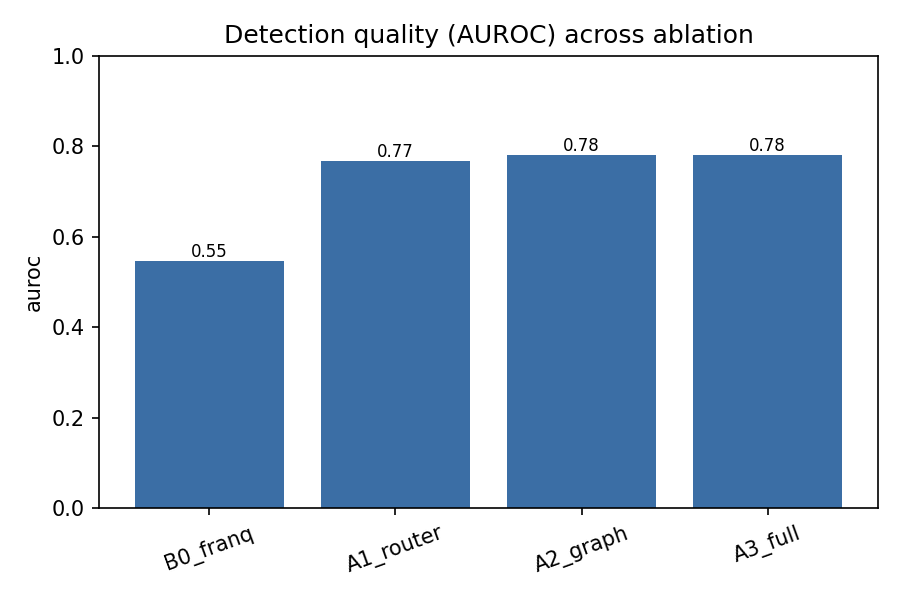

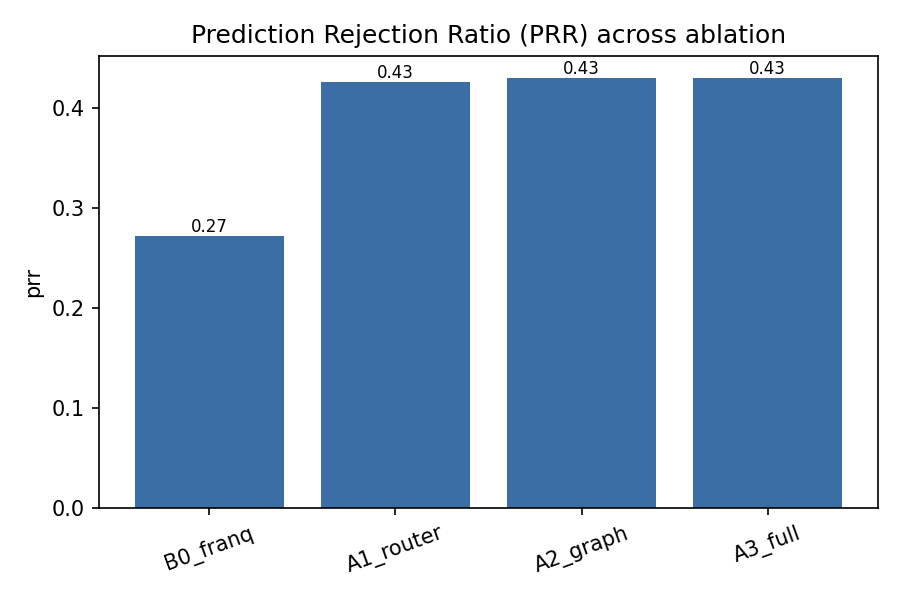

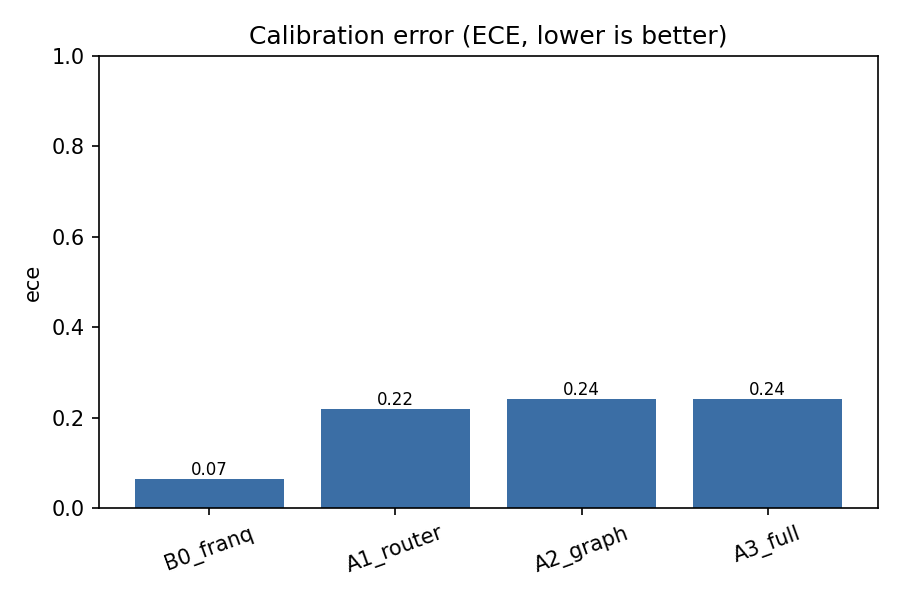

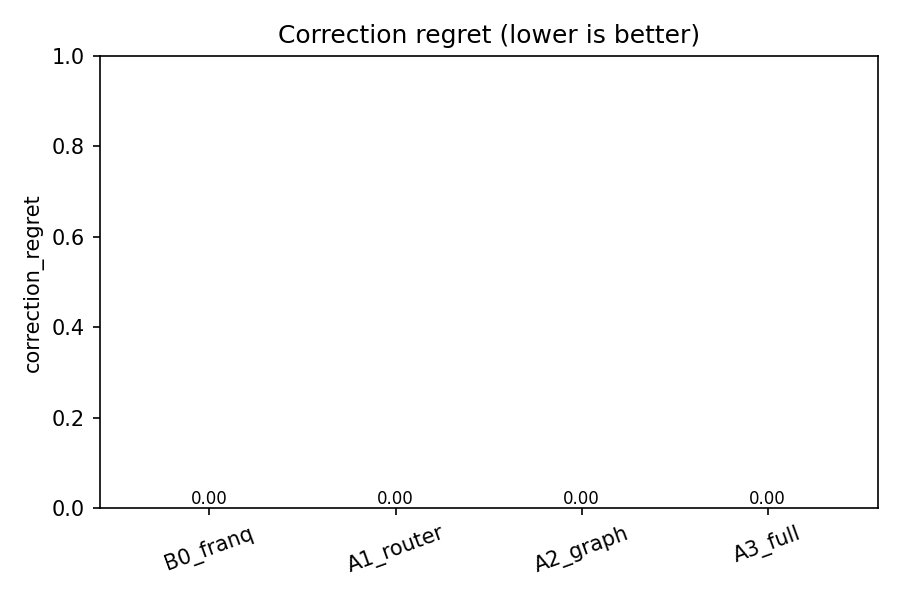

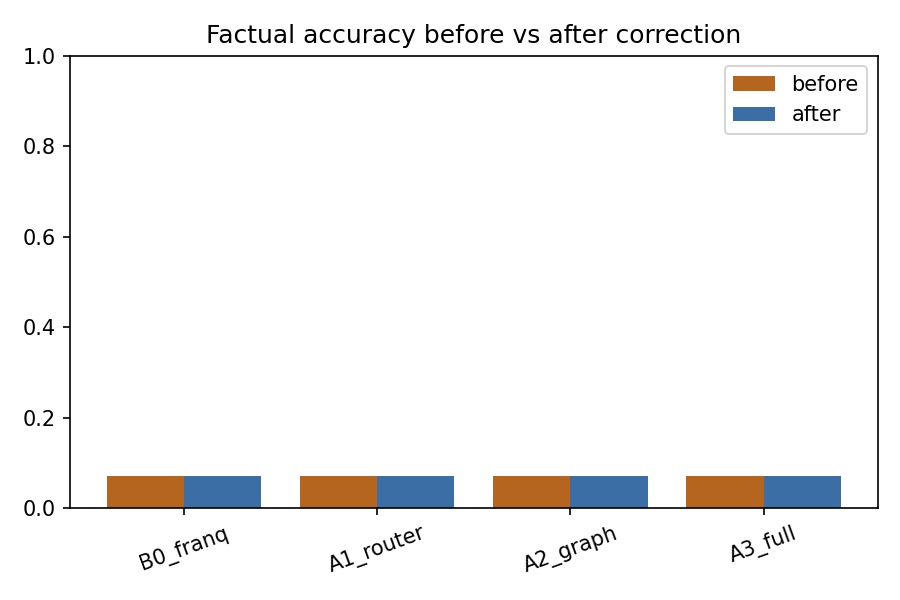

In [4]:
import pandas as pd
from IPython.display import display, Image
R = '/kaggle/working/results_popqa'
display(pd.read_csv(f'{R}/tables/ablation.csv'))
display(pd.read_csv(f'{R}/tables/regret_analysis.csv'))
for fig in ['fig_auroc.png','fig_prr.png','fig_ece.png','fig_regret.png','fig_factual_accuracy.png']:
    p = f'{R}/figures/{fig}'
    if os.path.exists(p):
        display(Image(p))

## Notes
- Everything in `/kaggle/working` is saved when you click **Save Version** (Commit) — download the CSVs/figures from the output afterwards.
- The signal cache (`/kaggle/working/results_popqa/signal_cache.json`) makes conditions 2–4 fast and re-runs near-instant.
- Too slow / tight on time? Lower `FRANQ_N`, or use `Qwen/Qwen2.5-1.5B-Instruct`.
- What to look for: ECE drop B0→A1 (Pillar 2); A2 ≥ A1 on AUROC/PRR/ECE (Pillar 1); A3 acc_after ≥ acc_before, low regret (Pillar 3).